## Seminar 00. Introduction to Jupyter Notebook — Data Processing

**Importing the required libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import interpolate
from scipy.signal import savgol_filter
from scipy.integrate import cumulative_trapezoid

**Engine parameters**

In [2]:
D = 0.265        # cylinder bore, m
S = 0.310        # piston stroke, m
n_mex = 0.82956  # mechanical efficiency
n = 1000         # engine speed, rpm
icyl = 12        # number of cylinders
eps = 17.5       # compression ratio
lamb = 0.235     # R/L

**Others constants**  

In [3]:
Rm = 8.314        # universal gas constant

**Importing the working process file (1D-calc)**

In [4]:
filename = 'engine450hp.ind'
IndDiag = pd.read_csv(filename, skiprows=list(range(17)) + [18], sep=r'\s+', engine='python', encoding='latin1')
IndDiag.head()

,Fi,Pc,Tc,V,Alf_w,P_1ring,G_bb,P_pist,x
0,180.0,4.53,369.4,0.018319,581.7,2.0367,0.000867,0.000,2.000000e+25
1,181.0,4.53,369.6,0.018318,582.2,2.0386,0.000868,0.018,2.000000e+25
2,182.0,4.54,369.8,0.018315,582.7,2.0406,0.000869,0.073,2.000000e+25
3,183.0,4.55,369.9,0.018310,583.3,2.0426,0.000870,0.165,2.000000e+25
4,184.0,4.55,370.2,0.018303,583.8,2.0447,0.000871,0.293,2.000000e+25


## Simple operation - data proccedings

### Assignment and mathematical operations

In [1]:
# Extract crank angle data
# Extract cylinder pressure and convert it to Pa
# Extract cylinder temperature
# Extract cylinder volume
# Extract heat transfer coefficient
# Extract heat release fraction
## an example Fi1d   = IndDiag['Fi']

In [6]:
Vh=np.pi*D*D/4*S
print('Engine displacement, %2.4E' % Vh)

Engine displacement, 1.7098E-02


In [2]:
# Find the maximum cylinder pressure
# Print the maximum cylinder pressure in MPa

In [3]:
# Find the maximum cycle temperature
# Print the maximum cycle temperature in K

### Engine performance

Indicated work per cycle:

$$ L_{i} = \oint p \, dV $$

$$ p_{i} = \frac{L_{i}}{V_h} $$


In [4]:
# Initialize indicated work
# Set the crank angle step
# Loop through the pressure and volume data
# Calculate the indicated work per cycle

# Print the indicated cycle work
# Calculate and print the indicated mean pressure

# Calculate the indicated engine power
# Print the indicated engine power

# Calculate and print the brake mean effective pressure
# Calculate and print the brake engine power

### Determining the combustion chamber volume

Current combustion chamber volume:

$$
V(\phi) = V_c + V_h - \frac{\pi D^2}{4} \left( (1 - \cos \phi) - \frac{\lambda}{4}(1 - \cos(2\phi)) \right)
$$

**Vectorization of calculations**

In [6]:
# Calculate the cc volume
# Create a crank angle array from 0 to 720 deg
# Calculate cylinder volume as a function of crank angle
# Check the compression ratio from the calculated volumes
# Round and print the result 

In [7]:
# Plot the calculated cylinder volume
# Plot the reference cylinder volume from file data

### Functions

In [10]:
# Define a function to calculate cylinder volume def Vcalc(Fi):
# Convert crank angle from degrees to radians
# Calculate the clearance volume
# Return the cylinder volume for the given crank angle

In [8]:
# Vcalc(75)

### Plotting graphs

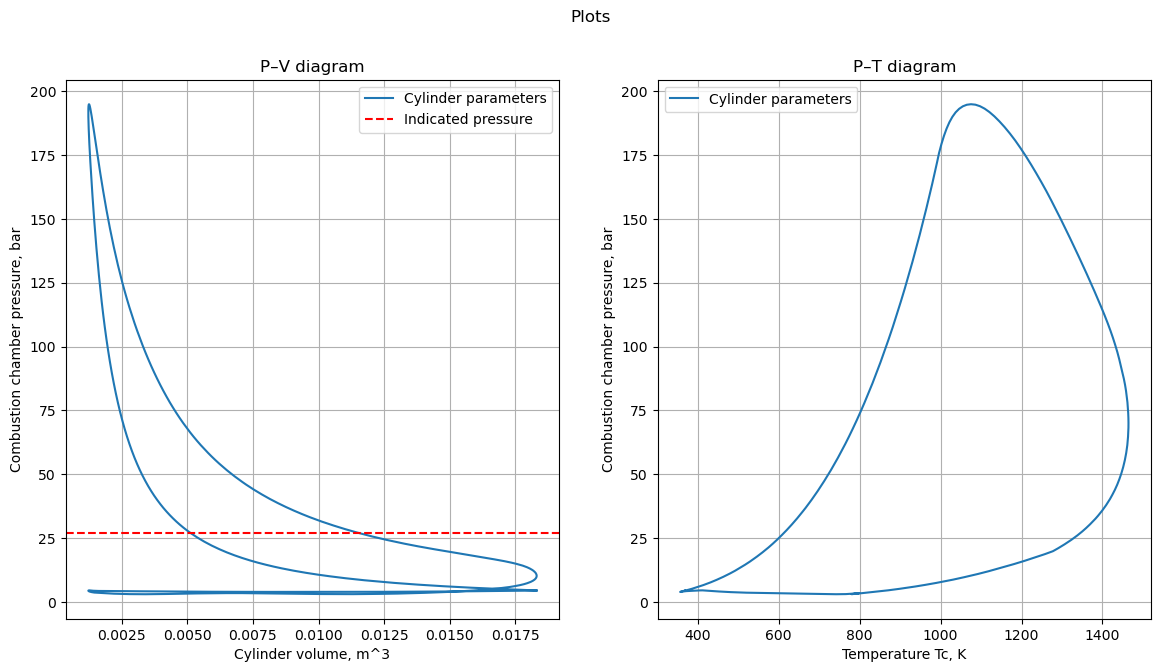

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# title
fig.suptitle('Plots')
ax[0].set_title('P–V diagram')
ax[1].set_title('P–T diagram')

# plots
ax[0].plot(Vks, Pc1d / 1e5, label='Cylinder parameters')
ax[0].axhline(y=Li / Vh / 1e5, color='r', linestyle='dashed', label='Indicated pressure')
ax[1].plot(Tc1d, Pc1d / 1e5, label='Cylinder parameters')

# axes
ax[0].set_ylabel('Combustion chamber pressure, bar')
ax[0].set_xlabel('Cylinder volume, m^3')
ax[1].set_ylabel('Combustion chamber pressure, bar')
ax[1].set_xlabel('Temperature Tc, K')

[[a.legend(), a.grid()] for a in ax]
plt.show()

You can use functions for this — that is, the plotting routine together with its settings can be placed inside a function body, and then only the variable values need to be passed to it.

In [15]:
# Define a function to plot a curve def plot_curve(): 
# Create a figure with a given size
# Set the plot title
# Plot the input data
# Set the y-axis label
# Set the x-axis label
# Show the plot

In [11]:
# Plot the heat release curve
# Set the plot title and axis labels

### Boolean indexing

**We need to get rid of the 1e25 values**

In [17]:
HR[HR>100] = 0

In [12]:
# Plot the heat release curve
# Set the plot title and axis labels

In [13]:
# Plot the heat release rate curve
# Set the plot title and axis labels

## Experimental data

We will work with experimental cylinder pressure data from 14 engine cycles; the data have already been labeled.

In [20]:
exp = pd.read_csv('IndDiagExp01.csv', encoding='latin-1', delimiter=',')
exp['Fi_deg'] = exp['Fi_deg'] +360
exp.head(5)

,Fi_deg,Pz 1,Pz 2,Pz 3,Pz 4,Pz 5,Pz 6,Pz 7,Pz 8,Pz 9,Pz 10,Pz 11,Pz 12,Pz 13,Pz 14
0,-171.280000,5.889545,7.439443,5.927579,5.707999,5.592402,6.513900,5.553394,5.752286,6.040520,7.928765,6.485551,5.203112,5.220912,6.263854
1,-171.081809,6.481532,7.216028,5.911507,5.541448,5.464857,6.145986,5.917485,5.888261,5.896877,7.696960,6.445414,5.403205,5.438102,6.208395
2,-170.883617,6.079407,7.000525,5.847283,5.273299,5.013560,6.119900,5.791228,5.849329,5.966900,7.774807,6.445317,5.738631,5.470340,6.004762
3,-170.685426,6.019278,7.773405,5.726893,5.288525,5.083200,6.498847,5.518945,5.327309,5.779773,7.957263,6.085828,5.512632,5.478400,5.553185
4,-170.487234,6.120460,6.743725,5.486296,5.653583,5.387550,6.388070,5.475034,5.419861,6.786419,8.164607,5.876011,5.587635,5.398048,5.652408


In [21]:
pz_columns = ['Pz 1', 'Pz 2', 'Pz 3', 'Pz 4', 'Pz 5', 'Pz 6', 'Pz 7', 'Pz 8', 'Pz 9', 'Pz 10', 'Pz 11', 'Pz 12', 'Pz 13', 'Pz 14']
exp[pz_columns] = exp[pz_columns]*1e5     # pressure is originally recorded in bar

Let us average the data over the cycles and add a new column.

In [22]:
exp['Pexp'] = exp[pz_columns].mean(axis=1)
exp.head(5)

,Fi_deg,Pz 1,Pz 2,Pz 3,Pz 4,Pz 5,Pz 6,Pz 7,Pz 8,Pz 9,Pz 10,Pz 11,Pz 12,Pz 13,Pz 14,Pexp
0,-171.280000,588954.4741,743944.3256,592757.9119,570799.8632,559240.1816,651389.9564,555339.3557,575228.5765,604051.9833,792876.5211,648555.0590,520311.2147,522091.1671,626385.4434,610851.859543
1,-171.081809,648153.1728,721602.8454,591150.7070,554144.7919,546485.6686,614598.6451,591748.4943,588826.0865,589687.7114,769695.9963,644541.3645,540320.5391,543810.1771,620839.5492,611828.982086
2,-170.883617,607940.7494,700052.5094,584728.3302,527329.9461,501355.9977,611990.0177,579122.8408,584932.9123,596690.0052,777480.7318,644531.6796,573863.0563,547033.9725,600476.2130,602680.640143
3,-170.685426,601927.8498,777340.5240,572689.3264,528852.5084,508320.0176,649884.7236,551894.4629,532730.9168,577977.2570,795726.2535,608582.7576,551263.2448,547839.9884,555318.4539,597167.734621
4,-170.487234,612046.0147,674372.5300,548629.5729,565358.2827,538754.9863,638807.0374,547503.3636,541986.0964,678641.9246,816460.6668,587601.1395,558763.5407,539804.7550,565240.8233,600997.909564


In [14]:
# use the previous code as example
# Create a figure for the pressure plot
# Set the figure title

# Plot experimental cylinder pressure
# Plot calculated cylinder pressure

# Set axis labels
# Add a legend and grid
# Show the plot

In [15]:
# Use the previous code to create the pressure plot
# Plot averaged experimental pressure
# Plot single-cycle experimental pressure
# Set the x and y axis limits
# Add axis labels, legend, and grid
# Show the plot

Averaging makes it possible to smooth the values. Let us see what the **dP/dFi** plot looks like.

In [25]:
dPdFi = np.gradient(exp['Pexp'], exp['Fi_deg'])

In [26]:
# You can try smoothing either with a moving average or with filters
# (for example, Savitzky–Golay, which suppresses high-frequency pulsations)
PSG = savgol_filter(exp['Pexp'], 30, 3)   # for example: 30 points, 3rd-order polynomial — for 6 degrees of crank rotation
dPSGdFi = np.gradient(PSG, exp['Fi_deg'])

Just in case, here is a video example of how this filter works.
https://youtu.be/1SvDZPvUo_I?si=st-Q4vaulbE5pJhD

In [16]:
# Use the previous code to create the dP/dFi plot
# Plot the experimental pressure derivative
# Plot the smoothed pressure derivative
# Plot the calculated pressure derivative
# Set axis labels
# Limit the crank angle range
# Add a legend and grid
# Show the plot

There are studies that also examine the variation of the second derivative of pressure with respect to crank angle to identify the combustion process.

The main thing is not to overdo the smoothing; for HRR reconstruction, we will use the smoothed values.

In [28]:
# exp['Pexp_smooth'] = exp['Pexp'].rolling(window=10, center=True, min_periods=1).mean()           # in practice, this is most likely how it is done in fast-response systems
exp['Pexp_smooth'] = PSG

In [17]:
# Use the previous code to create the pressure plot
# Plot the averaged pressure curve
# Plot pressure for each individual cycle using loop
# Plot the smoothed pressure curve
# Set axis labels
# Limit the crank angle range
# Add a legend and grid
# Show the plot

## Obtaining heat release characteristic data

In [30]:
Hu = 42.5*10**6           # let us assume the following value for the lower specific heating value

In [31]:
# since we do not have heat capacity data, we will use this value as a first approximation
cv = 25          

That also works

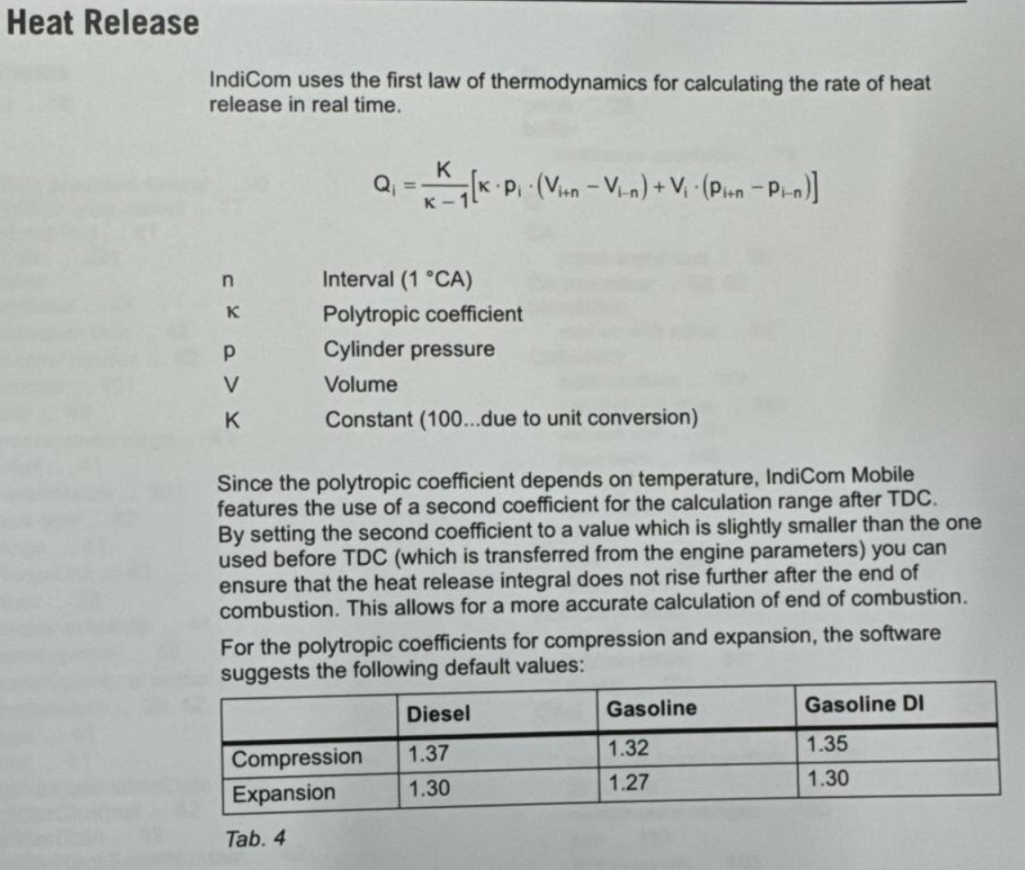

Let us define the terms for the First Law of Thermodynamics:

$$
\frac{dQ_{comb}}{d\phi} = \frac{dU}{d\phi} - \frac{dL}{d\phi} - \frac{dQ_w}{d\phi}
\qquad (1)
$$

$$
\frac{dU}{d\phi} = C_v \frac{d(MT)}{d\phi}
\quad | \quad pV = MRT \quad |
\quad = \frac{C_v}{R_m} \frac{d(pV)}{d\phi}
\qquad (2)
$$

$$
\frac{dL}{d\phi} = -p \frac{dV}{d\phi}
\qquad (3)
$$

Then the expression for the heat released during combustion takes the form:

$$
\frac{dQ_{comb}}{d\phi} =
\left( \frac{C_v}{R_m} + 1 \right) p \frac{dV}{d\phi}
+ \frac{C_v}{R_m} V \frac{dp}{d\phi}
- \frac{dQ_w}{d\phi}
\qquad (4)
$$

In [32]:
qc = 1.47e-03                                              # assume that the experimental cycle fuel delivery is as follows

In [18]:
# Convert crank angle data to a NumPy array
# Convert smoothed pressure data to a NumPy array
# Calculate cylinder volume versus crank angle
# Calculate the volume derivative with respect to crank angle
# Calculate the pressure derivative with respect to crank angle
# Calculate the heat release rate

Plot of heat release $ \dfrac{dQ_{comb}}{d\phi} $ versus crank angle

In [19]:
# Create a figure for the heat release plot
# Set the figure title
# Plot the heat release rate versus crank angle
# Set axis labels
# Add reference lines for zero level and TDC
# Show the plot

Although the start of combustion is actually **7 crank-angle degrees before TDC**, it is reasonable to reconstruct the heat release characteristic using the **Wiebe function starting from 7 crank-angle degrees after TDC**.

The start of combustion was taken as the crank angle corresponding to **5%** of the cumulative heat release (**CA05**), and the end of combustion as the angle corresponding to **95%** of the cumulative heat release (**CA95**). This approach makes it possible to exclude the influence of the weakly pronounced initial and final stages of the process, which is especially important when analyzing experimental indicator diagrams.

In [35]:
strt = 2643
end = 3300

mask = (Fi >= Fi[strt]) & (Fi < Fi[end])
Qtot = cumulative_trapezoid(dQcdFi[strt:end], Fi[strt:end], initial=0)

CA05 = np.interp(0.05, Qtot / Qtot[-1], Fi[mask])
CA50 = np.interp(0.50, Qtot / Qtot[-1], Fi[mask])
CA95 = np.interp(0.95, Qtot / Qtot[-1], Fi[mask])

print(f'Start of combustion angle, Fi = {CA05:0.2f} deg')
print(f'End of combustion angle, Fi = {CA95:0.2f} deg')
print(f'Combustion duration, Fi = {(CA95 - CA05):0.2f} deg')

Start of combustion angle, Fi = 366.33 deg
End of combustion angle, Fi = 443.41 deg
Combustion duration, Fi = 77.08 deg


In [20]:
# Select the crank-angle interval for combustion analysis
# Create a figure for the heat release plot
# Plot the heat release rate in the selected interval
# Add a horizontal reference line
# Mark the start and end of combustion
# Add a grid and legend
# Show the plot

In [37]:
f = interpolate.interp1d(Fi, dQcdFi)
fi = np.linspace(CA05, CA95, 77).astype(int)
dQcdFi_tab = f(fi)   # use interpolation function returned by `interp1d`

In [21]:
# Select the crank-angle interval for comparison
# Create a figure for the heat release plot
# Plot the original experimental heat release rate
# Plot the tabulated heat release rate
# Add a grid and legend
# Show the plot

Heat release rate:

$$
\frac{dQ_{comb}}{d\phi} = H_u \frac{dx}{d\phi} q_c
$$

Plot of  $ \dfrac{dx}{d\phi} $ versus crank angle

It is necessary to store **dXdFi** in a separate variable over the interval where combustion takes place.

In [22]:
# Calculate the normalized heat release rate

# Create a figure for the heat release rate plot
# Set the figure title
# Plot the reconstructed heat release rate
# Plot the reference heat release rate from the 1D model
# Set axis labels
# Add a grid and legend
# Show the plot

## Using the double Wiebe function for combustion modeling

For a diesel engine, it can be written in the following form:

$$
\frac{dx_{dies}}{d\phi} = \frac{dx_{prem}}{d\phi} + \frac{dx_{diff}}{d\phi}
$$

For premixed combustion:

$$
\frac{dx_{prem}}{d\phi} =
\chi_t
\left[\frac{m_t}{\phi_{comb}}\right]
\left[\frac{\phi}{\phi_{comb}}\right]
\exp\left(
-\frac{m_t}{m_t+1}
\left[\frac{\phi}{\phi_{comb}}\right]^{m_t+1}
\right)
$$

For diffusion combustion:

$$
\frac{dx_{diff}}{d\phi} =
(1-\chi_t)\, C
\left[\frac{m_v+1}{\phi_z}\right]
\left[\frac{\phi}{\phi_z}\right]
\exp\left(
-C\left[\frac{\phi}{\phi_z}\right]^{m_v+1}
\right)
$$

$ \chi_t $ — fraction of fuel burned by the kinetic mechanism;

$ m_t $ — kinetic combustion shape factor;

$ \phi_{comb} $ — crank angle corresponding to the maximum rate of kinetic combustion;

$ m_v $ — volumetric combustion shape factor;

$ C = -\ln[1-\Delta x] $

$ \Delta x $ — fraction of fuel burned over the entire process (usually taken as approximately 0.99);

$ \phi_z $ — total combustion duration.

It is necessary to determine the constants, except for those that can be taken directly from the plot.

In [40]:
ksi=0.03
dx=0.99
mt=2
mv=0.85
Fiz=13                       # get from hrr
Fic=77                       # get from hrr 
C=-np.log(1-dx)

Write a function to determine the heat release rate.

In [23]:
# Define a function for the heat release rate
# Calculate the premixed combustion term
# Calculate the diffusion combustion term
# Return the combined heat release rate

In [24]:
# Create a crank-angle array for the calculation
# Calculate the heat release rate using the model function

In [25]:
# Create a figure for the heat release rate comparison
# Set the figure title
# Plot the experimental heat release rate
# Plot the reference heat release rate from the 1D model
# Plot the initial Wiebe approximation
# Set axis labels
# Add a grid and legend
# Show the plot

This does not seem to be the optimal solution

### Fitting the coefficients in the Wiebe function

This approach is not entirely correct, because the purpose of using the Wiebe function is to generalize the data. However, to demonstrate the capabilities of Python, we can try to determine the parameters that would allow the heat release characteristic in this particular case to be approximated as accurately as possible.

Initial value vector

In [44]:
X0 = [ksi, mt, mv, Fic]
X0

[0.03, 2, 0.85, 77]

Definition of the objective function

In [26]:
# Define the objective function
# Create a crank-angle array for the fitting interval
# Extract model parameters from the input vector
# Calculate the difference between the model and experimental data
# Return the norm of the residual vector

Minimization of the objective function  

In [46]:
bounds = [(0, None), (0, None), (0, None), (0, None)] 
res = minimize(target, X0, bounds=bounds, method="SLSQP")
res 

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.017830997441595216
           x: [ 2.736e-01  2.073e+00  9.375e-01  7.701e+01]
         nit: 7
         jac: [-3.655e-04 -4.117e-04  6.323e-05 -5.725e-04]
        nfev: 37
        njev: 7
 multipliers: []

Final coefficient values

In [47]:
ksi =res.x[0] 
mt = res.x[1] 
mv = res.x[2] 
Fic = res.x[3] 
print ('ksi = ', ksi)
print ('mt = ', mt)
print ('mv = ', mv)
print ('Fic = ', Fic)

ksi =  0.2736014928665912
mt =  2.0733113806613175
mv =  0.9375159684223004
Fic =  77.01202220108016


In [28]:
# Create a crank-angle array for the calculation
# Calculate the heat release rate using the model function and optimal coefficients

In [27]:
# Create a figure for the fitted heat release rate comparison
# Set the figure title
# Plot the experimental heat release rate
# Plot the reference heat release rate from the 1D model
# Plot the optimized Wiebe approximation
# Set axis labels
# Add a grid and legend
# Show the plot